In [21]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import pygame
import sys
import os
import pickle

# Константы для визуализации
RENDER_FPS = 30
CELL_SIZE = 50
COLOR_BG = (30, 30, 35)      # Темный фон (предпочтение пользователя)
COLOR_WALL = (50, 55, 65)    # Стены
COLOR_COURIER = (255, 215, 0)# Курьер (Золотой)
COLOR_GOAL = (0, 200, 83)    # Цель (Зеленый)
COLOR_TEXT = (255, 255, 255) # Текст

**Среда**

In [22]:
class CourierEnv(gym.Env):
    """
    Задание 1: Среда на базе клетчатого поля.
    Задание 2: Определение State, Action, Reward.
    """
    metadata = {'render_modes': ['human']}

    def __init__(self):
        super().__init__()
        
        # 1. Карта лабиринта (1 - стена, 0 - дорога, 3 - цель)
        self.grid_map = [
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 0, 0, 0, 1, 0, 0, 0, 0, 1],
            [1, 1, 1, 0, 1, 0, 1, 1, 0, 1],
            [1, 0, 0, 0, 0, 0, 1, 0, 0, 1],
            [1, 0, 1, 1, 1, 1, 1, 0, 1, 1],
            [1, 0, 0, 0, 1, 0, 0, 0, 0, 1],
            [1, 1, 1, 0, 1, 0, 1, 1, 0, 1],
            [1, 0, 0, 0, 0, 0, 1, 3, 0, 1],
            [1, 0, 1, 1, 1, 1, 1, 1, 0, 1],
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
        ]
        
        self.rows = len(self.grid_map)
        self.cols = len(self.grid_map[0])
        
        # Поиск координат цели
        self.goal_pos = None
        self.free_positions = []
        for r in range(self.rows):
            for c in range(self.cols):
                if self.grid_map[r][c] == 3:
                    self.goal_pos = (c, r)
                elif self.grid_map[r][c] == 0:
                    self.free_positions.append((c, r))

        # 2. Действия (Action Space): 4 действия
        # 0: Вперед, 1: Назад, 2: Поворот влево, 3: Поворот вправо
        self.action_space = spaces.Discrete(4)
        
        # 3. Состояние (State Space): Дискретное
        # Для Q-Learning используем индекс состояния: x + y*cols + angle*cols*rows
        # Это покрывает положение (x,y) и угол поворота.
        # Расстояние и угол до цели вычисляются детерминировано из координат на статичной карте.
        self.observation_space = spaces.Discrete(self.rows * self.cols * 4)
        
        # Параметры агента
        self.courier_pos = None
        self.courier_angle = 0  # 0: East, 1: South, 2: West, 3: North
        self.steps_taken = 0
        self.max_steps = 100
        
        # Для Pygame
        self.window = None
        self.clock = None

    def _get_state_index(self):
        """Преобразует координаты и угол в уникальный индекс состояния"""
        x, y = self.courier_pos
        return int(x + y * self.cols + self.courier_angle * self.cols * self.rows)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        
        # Рандомизация старта (для Задания 4 - разные начальные условия)
        start_pos = self.free_positions[np.random.randint(len(self.free_positions))]
        self.courier_pos = list(start_pos)
        self.courier_angle = np.random.randint(4)
        self.steps_taken = 0
        
        return self._get_state_index(), {}

    def step(self, action):
        self.steps_taken += 1
        
        # --- Задание 2.c: Награда (Reward) ---
        reward = -1  # iii. -1 за каждый шаг (штраф за время)
        
        old_dist = abs(self.goal_pos[0] - self.courier_pos[0]) + \
                   abs(self.goal_pos[1] - self.courier_pos[1])
        
        dx, dy = 0, 0
        moved = False
        
        # Обработка действий
        if action == 0: # i. Движение вперёд
            dirs = [(1,0), (0,1), (-1,0), (0,-1)]
            dx, dy = dirs[self.courier_angle]
            moved = True
        elif action == 1: # ii. Движение назад
            dirs = [(-1,0), (0,-1), (1,0), (0,1)]
            dx, dy = dirs[self.courier_angle]
            moved = True
        elif action == 2: # iii. Поворот влево
            self.courier_angle = (self.courier_angle + 1) % 4
        elif action == 3: # iv. Поворот вправо
            self.courier_angle = (self.courier_angle - 1) % 4
            
        # Физика движения
        if moved:
            next_x = self.courier_pos[0] + dx
            next_y = self.courier_pos[1] + dy
            
            # Проверка столкновений
            if 0 <= next_x < self.cols and 0 <= next_y < self.rows:
                if self.grid_map[int(next_y)][int(next_x)] != 1:
                    self.courier_pos = [int(next_x), int(next_y)]
                else:
                    # ii. -10 за столкновение с препятствием
                    reward -= 10 
            else:
                # Выход за границы тоже считаем столкновением
                reward -= 10

        new_dist = abs(self.goal_pos[0] - self.courier_pos[0]) + \
                   abs(self.goal_pos[1] - self.courier_pos[1])
        
        # iv. +10 за приближение к цели / v. -5 за удаление
        if new_dist < old_dist:
            reward += 10
        elif new_dist > old_dist:
            reward -= 5
            
        terminated = False
        truncated = False

        # i. +100 за попадание в цель (достижение координат)
        if tuple(self.courier_pos) == self.goal_pos:
            reward += 100
            terminated = True
            
        if self.steps_taken >= self.max_steps:
            truncated = True
            
        return self._get_state_index(), reward, terminated, truncated, {}

    def render(self):
        if self.window is None:
            pygame.init()
            w = self.cols * CELL_SIZE
            h = self.rows * CELL_SIZE + 50
            self.window = pygame.display.set_mode((w, h))
            pygame.display.set_caption("Courier RL Lab 4")
            self.clock = pygame.time.Clock()
            self.font = pygame.font.SysFont("Consolas", 16)

        self.window.fill(COLOR_BG)
        
        # Отрисовка карты
        for r in range(self.rows):
            for c in range(self.cols):
                x = c * CELL_SIZE
                y = r * CELL_SIZE
                cell = self.grid_map[r][c]
                if cell == 1:
                    pygame.draw.rect(self.window, COLOR_WALL, (x, y, CELL_SIZE, CELL_SIZE))
                elif cell == 3:
                    pygame.draw.circle(self.window, COLOR_GOAL, (x + CELL_SIZE//2, y + CELL_SIZE//2), CELL_SIZE//3)
                    
        # Отрисовка Курьера
        ax = self.courier_pos[0] * CELL_SIZE + CELL_SIZE//2
        ay = self.courier_pos[1] * CELL_SIZE + CELL_SIZE//2
        dirs = [(1, 0), (0, 1), (-1, 0), (0, -1)]
        dx, dy = dirs[self.courier_angle]
        
        pygame.draw.line(self.window, COLOR_COURIER, (ax, ay), (ax + dx*15, ay + dy*15), 4)
        pygame.draw.circle(self.window, COLOR_COURIER, (ax, ay), 8)
        
        txt = self.font.render(f"Steps: {self.steps_taken}", True, COLOR_TEXT)
        self.window.blit(txt, (10, self.rows * CELL_SIZE + 10))
        
        pygame.display.flip()
        self.clock.tick(RENDER_FPS)

    def close(self):
        if self.window is not None:
            pygame.quit()
            self.window = None

**Агент**

In [23]:
class QLearningAgent:
    """
    Задание 3: Реализация агента Q-Learning
    """
    def __init__(self, state_size, action_size, lr=0.2, gamma=0.95, epsilon=1.0):
        self.q_table = np.zeros((state_size, action_size))
        self.action_size = action_size
        self.lr = lr
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.9995

    def get_action(self, state):
        # ε-жадная стратегия
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.action_size)
        return np.argmax(self.q_table[state])

    def learn(self, state, action, reward, next_state, done):
        current_q = self.q_table[state][action]
        max_next_q = 0 if done else np.max(self.q_table[next_state])
        new_q = current_q + self.lr * (reward + self.gamma * max_next_q - current_q)
        self.q_table[state][action] = new_q

    def update_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

def train_courier():
    env = CourierEnv()
    agent = QLearningAgent(
        state_size=env.observation_space.n,
        action_size=env.action_space.n
    )
    
    episodes = 3000
    rewards_history = []
    
    print("Начало обучения...")
    for e in range(episodes):
        state, _ = env.reset()
        total_reward = 0
        done = False
        trunc = False
        
        while not (done or trunc):
            action = agent.get_action(state)
            next_state, reward, done, trunc, _ = env.step(action)
            agent.learn(state, action, reward, next_state, done or trunc)
            state = next_state
            total_reward += reward
            
        agent.update_epsilon()
        rewards_history.append(total_reward)
        
        if (e + 1) % 500 == 0:
            avg_r = np.mean(rewards_history[-100:])
            print(f"Эпизод {e+1}/{episodes} | Средняя награда (100 эп.): {avg_r:.2f} | Epsilon: {agent.epsilon:.3f}")
            
    env.close()
    
    # Сохранение модели
    with open('courier_agent.pkl', 'wb') as f:
        pickle.dump(agent.q_table, f)
        
    return agent, rewards_history

# Запуск обучения
trained_agent, history = train_courier()

Начало обучения...
Эпизод 500/3000 | Средняя награда (100 эп.): -60.96 | Epsilon: 0.779
Эпизод 1000/3000 | Средняя награда (100 эп.): 70.43 | Epsilon: 0.606
Эпизод 1500/3000 | Средняя награда (100 эп.): 119.17 | Epsilon: 0.472
Эпизод 2000/3000 | Средняя награда (100 эп.): 136.41 | Epsilon: 0.368
Эпизод 2500/3000 | Средняя награда (100 эп.): 141.88 | Epsilon: 0.286
Эпизод 3000/3000 | Средняя награда (100 эп.): 145.48 | Epsilon: 0.223


**Обучение**

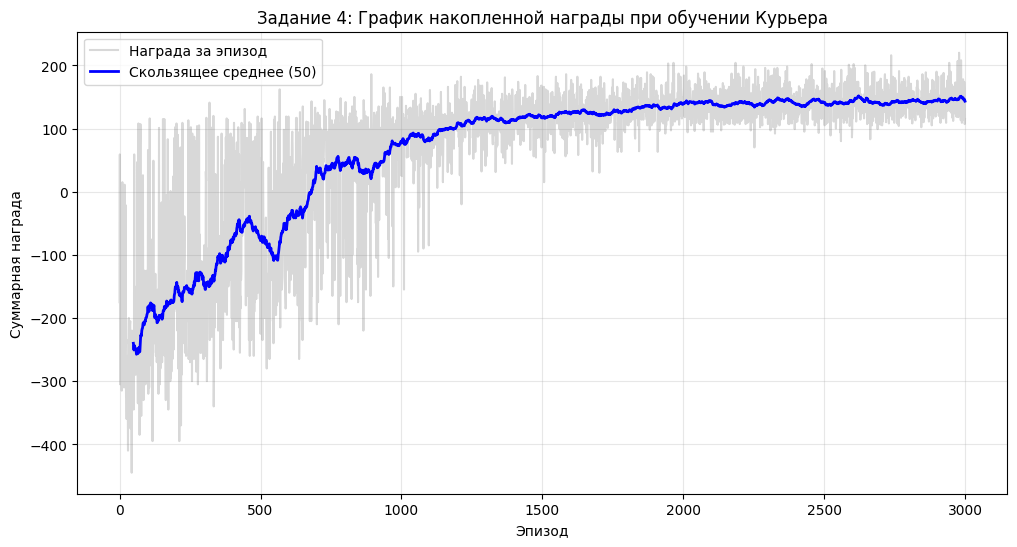


--- Тестирование агента (Задание 4.3) ---
Тест 1: Случайный старт
Старт: (3, 2) | Результат: УСПЕХ | Шагов: 28
Тест 2: Сложный старт (1, 7)
Старт: (1, 7) | Результат: УСПЕХ | Шагов: 17
Тест 3: Сложный старт (3, 3)
Старт: (3, 3) | Результат: УСПЕХ | Шагов: 25

Лабораторная работа завершена.


In [24]:
# 1. Визуализация процесса обучения (График)
plt.figure(figsize=(12, 6))
plt.plot(history, alpha=0.3, color='gray', label='Награда за эпизод')

# Скользящее среднее
window = 50
if len(history) > window:
    ma = np.convolve(history, np.ones(window)/window, mode='valid')
    plt.plot(range(window-1, len(history)), ma, color='blue', linewidth=2, label=f'Скользящее среднее ({window})')

plt.title('Задание 4: График накопленной награды при обучении Курьера')
plt.xlabel('Эпизод')
plt.ylabel('Суммарная награда')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Тестирование на разных начальных условиях
print("\n--- Тестирование агента (Задание 4.3) ---")

def test_agent_on_map(start_pos_override=None):
    env = CourierEnv()
    # Загружаем обученную таблицу
    agent = QLearningAgent(env.observation_space.n, env.action_space.n, epsilon=0.0)
    if os.path.exists('courier_agent.pkl'):
        with open('courier_agent.pkl', 'rb') as f:
            agent.q_table = pickle.load(f)
    
    # Если передана конкретная позиция, ставим туда (через модификацию reset логики вручную для теста)
    if start_pos_override:
        env.courier_pos = list(start_pos_override)
        env.courier_angle = 0
        env.steps_taken = 0
        state = env._get_state_index()
    else:
        state, _ = env.reset()
        
    done = False
    trunc = False
    path = [tuple(env.courier_pos)]
    
    while not (done or trunc):
        action = agent.get_action(state)
        next_state, reward, done, trunc, _ = env.step(action)
        state = next_state
        path.append(tuple(env.courier_pos))
        env.render() # Визуализация прохождения
        
    status = "УСПЕХ" if reward > 50 else "ПРОВАЛ"
    print(f"Старт: {path[0]} | Результат: {status} | Шагов: {len(path)}")
    pygame.time.wait(1000) # Пауза между тестами
    env.close()
    return status

# Тест 1: Случайный старт (стандартный reset)
print("Тест 1: Случайный старт")
test_agent_on_map()

# Тест 2: Сложный старт (далеко от цели)
print("Тест 2: Сложный старт (1, 7)")
test_agent_on_map(start_pos_override=(1, 7))

# Тест 3: Другой сложный старт
print("Тест 3: Сложный старт (3, 3)")
test_agent_on_map(start_pos_override=(3, 3))

print("\nЛабораторная работа завершена.")

In [ ]:
# def run_visual_demo():
#     # Инициализация Pygame
#     if not pygame.get_init():
#         pygame.init()
        
#     MAP_W = 10 * CELL_SIZE
#     MAP_H = 10 * CELL_SIZE
#     UI_H = 80
#     screen = pygame.display.set_mode((MAP_W, MAP_H + UI_H))
#     pygame.display.set_caption("Courier RL Visualization")
#     clock = pygame.time.Clock()
#     font = pygame.font.SysFont("Consolas", 18)
    
#     env = GridCourierEnv()
    
#     # Создаем агента и загружаем предобученную модель
#     agent = QAgent(epsilon=0.1) # Начинаем с низким epsilon (почти умный)
#     agent.load()
    
#     state = env.reset()
#     episode = 0
#     mode = "DEMO" # или "TRAIN"
    
#     running = True
#     while running:
#         # 1. Events
#         for event in pygame.event.get():
#             if event.type == pygame.QUIT:
#                 running = False
#             if event.type == pygame.KEYDOWN:
#                 if event.key == pygame.K_SPACE:
#                     mode = "TRAIN" if mode == "DEMO" else "DEMO"
#                     agent.epsilon = 1.0 if mode == "TRAIN" else 0.05
#                     print(f"Mode: {mode}")
#                 if event.key == pygame.K_r:
#                     state = env.reset()

#         # 2. Logic Step
#         action = agent.get_action(state)
#         next_state, reward, done, trunc = env.step(action)
        
#         # Если режим тренировки - учимся
#         if mode == "TRAIN":
#             agent.learn(state, action, reward, next_state, done or trunc)
#             agent.update_epsilon()
            
#         state = next_state
        
#         if done or trunc:
#             episode += 1
#             state = env.reset()

#         # 3. Render
#         screen.fill(COLOR_BG)
        
#         # Map
#         for r in range(env.rows):
#             for c in range(env.cols):
#                 x, y = c * CELL_SIZE, r * CELL_SIZE
#                 cell = env.grid_map[r][c]
#                 if cell == 1:
#                     pygame.draw.rect(screen, COLOR_WALL, (x, y, CELL_SIZE, CELL_SIZE))
#                     # Декор стены
#                     pygame.draw.rect(screen, COLOR_WALL_TOP, (x+5, y+5, CELL_SIZE-10, CELL_SIZE-10))
#                 elif cell == 3:
#                     pygame.draw.circle(screen, COLOR_GOAL, (x + CELL_SIZE//2, y + CELL_SIZE//2), CELL_SIZE//3)
        
#         # Courier
#         cx = env.courier_pos[0] * CELL_SIZE + CELL_SIZE//2
#         cy = env.courier_pos[1] * CELL_SIZE + CELL_SIZE//2
#         dirs = [(1, 0), (0, 1), (-1, 0), (0, -1)]
#         dx, dy = dirs[env.courier_angle]
        
#         # Линия направления
#         pygame.draw.line(screen, COLOR_COURIER, (cx, cy), (cx + dx*20, cy + dy*20), 4)
#         # Тело
#         pygame.draw.circle(screen, COLOR_COURIER, (cx, cy), 10)
        
#         # UI Panel
#         pygame.draw.rect(screen, (40, 40, 45), (0, MAP_H, MAP_W, UI_H))
        
#         texts = [
#             f"Episode: {episode}",
#             f"Mode: {mode} (Press SPACE)",
#             f"Epsilon: {agent.epsilon:.3f}",
#             f"Pos: {env.courier_pos} | Angle: {env.courier_angle}"
#         ]
        
#         for i, txt in enumerate(texts):
#             surf = font.render(txt, True, COLOR_TEXT)
#             screen.blit(surf, (10, MAP_H + 10 + i*20))
            
#         pygame.display.flip()
#         clock.tick(RENDER_FPS)

#     pygame.quit()

# # Запуск визуализации
# run_visual_demo()

In [26]:
# def run_demo():
#     # 1. Явная инициализация Pygame перед созданием окна
#     if not pygame.get_init():
#         pygame.init()
    
#     env = GridCourierEnv()
    
#     # 2. Создаем агента и загружаем веса
#     test_agent = QLearningAgent(
#         state_size=env.observation_space.n,
#         action_size=env.action_space.n,
#         epsilon=0.0 # Жадная политика (без случайных действий)
#     )
    
#     # Пытаемся загрузить модель, если файла нет - предупреждаем
#     try:
#         test_agent.load_model("courier_agent.pkl")
#     except FileNotFoundError:
#         print("ОШИБКА: Файл 'courier_agent.pkl' не найден!")
#         print("Пожалуйста, сначала запустите ячейку с обучением (Блок 4).")
#         return

#     # Запустим 3 демонстрационных заезда
#     for i in range(3):
#         state, _ = env.reset()
#         done = False
#         trunc = False
#         total_r = 0
        
#         print(f"\n--- Demo Run {i+1} ---")
        
#         while not (done or trunc):
#             # Обработка событий Pygame (обязательно для отклика окна)
#             for event in pygame.event.get():
#                 if event.type == pygame.QUIT:
#                     env.close()
#                     pygame.quit()
#                     return
            
#             action = test_agent.get_action(state)
#             next_state, reward, done, trunc, _ = env.step(action)
            
#             # Рендеринг
#             env.render() 
            
#             state = next_state
#             total_r += reward
            
#         status = "SUCCESS" if total_r > 5 else "FAILED"
#         print(f"Result: {status} | Reward: {total_r:.2f}")
        
#         # Небольшая пауза, чтобы увидеть финальное состояние
#         pygame.time.wait(1000) 
        
#     env.close()
#     # Не вызываем pygame.quit() здесь, чтобы можно было запустить демо снова 
#     # без переинициализации ядра, если понадобится.
#     print("Demo finished.")

# run_demo()